In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings("ignore")

# load predictions
pred_df = pd.read_parquet("../data/predictions_v3.parquet")
ic_series = pd.read_parquet("../data/ic_series_v3.parquet")["ic"]

print(f"predictions: {pred_df.shape}")
print(f"ic series  : {len(ic_series)} months")
print(pred_df.head())

predictions: (10911, 2)
ic series  : 22 months
                       pred    actual
Date       Ticker                    
2023-02-28 A      -0.003483 -0.041797
           AAPL    0.003145  0.106030
           ABBV    0.003048  0.042039
           ABNB    0.010740 -0.020942
           ABT     0.005038 -0.015078


In [2]:
# ── QUINTILE PORTFOLIO CONSTRUCTION ──────────────────────────────
# On each month, rank stocks by predicted score into 5 buckets
# Track how each bucket actually performed

monthly_returns = []

dates = pred_df.index.get_level_values("Date").unique().sort_values()

for date in dates:
    month_data = pred_df.loc[date].copy()
    
    # rank stocks into 5 quintiles by predicted score
    month_data["quintile"] = pd.qcut(
        month_data["pred"], 
        q=5, 
        labels=[1, 2, 3, 4, 5]
    )
    
    # average actual return for each quintile that month
    for q in [1, 2, 3, 4, 5]:
        q_stocks = month_data[month_data["quintile"] == q]
        avg_return = q_stocks["actual"].mean()
        monthly_returns.append({
            "date"    : date,
            "quintile": q,
            "return"  : avg_return
        })

returns_df = pd.DataFrame(monthly_returns)
returns_df = returns_df.pivot(index="date", columns="quintile", values="return")
returns_df.columns = [f"Q{c}" for c in returns_df.columns]

print(f"quintile returns shape: {returns_df.shape}")
print(returns_df.round(4))

quintile returns shape: (22, 5)
                Q1      Q2      Q3      Q4      Q5
date                                              
2023-02-28  0.0064 -0.0125 -0.0053  0.0050  0.0051
2023-03-31 -0.0035 -0.0027  0.0099 -0.0033  0.0028
2023-04-28  0.0043 -0.0057 -0.0246 -0.0098 -0.0017
2023-05-31  0.0132  0.0056 -0.0096 -0.0148 -0.0126
2023-06-30  0.0108 -0.0139 -0.0098  0.0091 -0.0075
2023-07-31  0.0035  0.0088 -0.0046 -0.0088  0.0008
2023-08-31  0.0051  0.0036 -0.0001 -0.0057 -0.0028
2023-09-29  0.0087 -0.0004  0.0017 -0.0019  0.0013
2023-10-31 -0.0024 -0.0013 -0.0139 -0.0057  0.0085
2023-11-30  0.0010  0.0017 -0.0016 -0.0035 -0.0088
2023-12-29 -0.0205 -0.0039  0.0079 -0.0006  0.0147
2024-01-31 -0.0247 -0.0199 -0.0097  0.0036  0.0200
2024-02-29  0.0003 -0.0031 -0.0020 -0.0136  0.0113
2024-03-28  0.0105  0.0019  0.0060 -0.0131 -0.0068
2024-04-30 -0.0163 -0.0055 -0.0093 -0.0004  0.0153
2024-05-31 -0.0096 -0.0107  0.0046 -0.0013  0.0104
2024-06-28  0.0061  0.0062  0.0073  0.0027 -0.0164

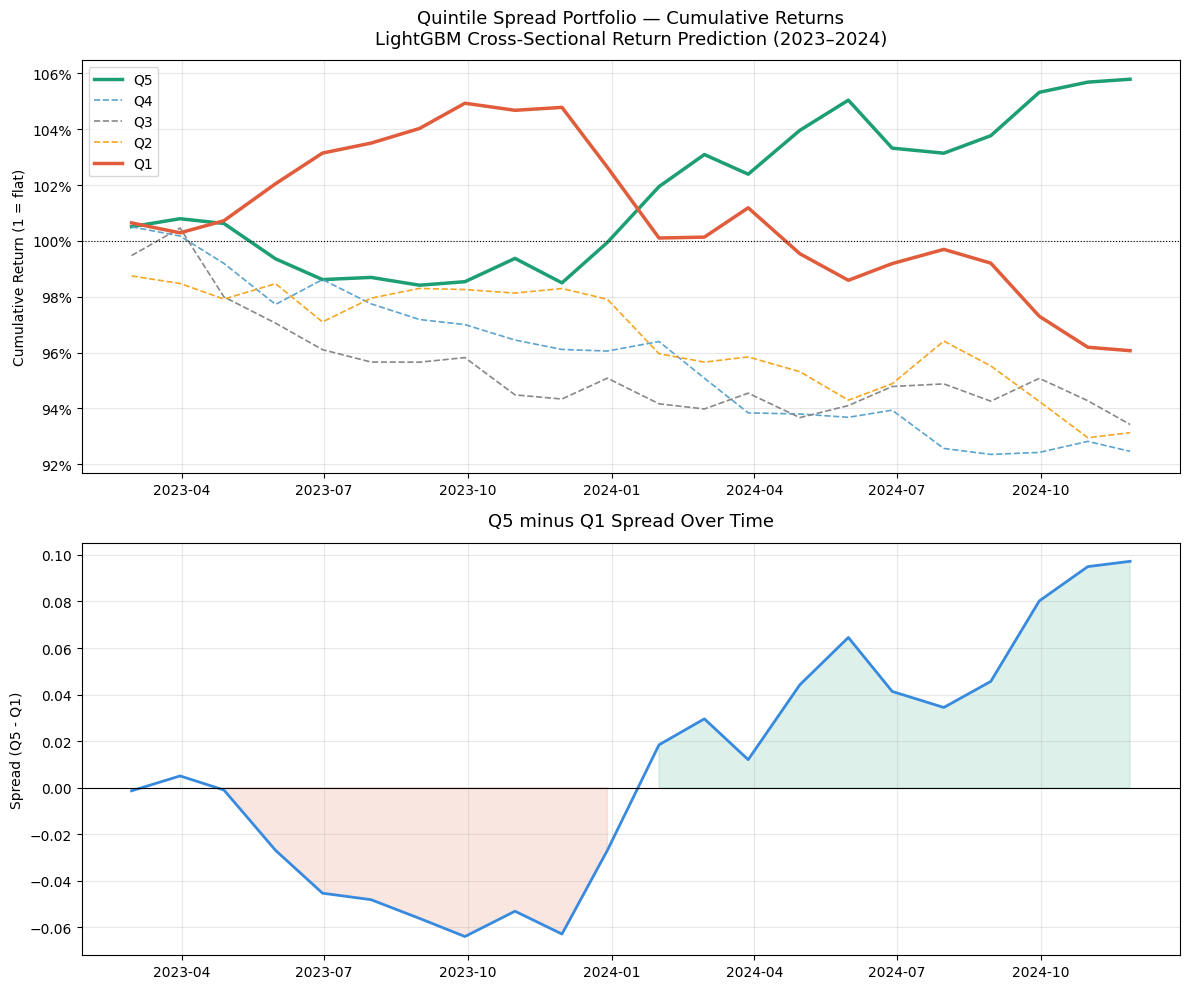

fan chart saved


In [3]:
# ── QUINTILE FAN CHART ────────────────────────────────────────────
# Cumulative returns of each quintile over time
# If model works: Q5 highest, Q1 lowest, clean fan shape

cumulative = (1 + returns_df).cumprod()

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# ── top chart: cumulative returns fan ────────────────────────────
ax1 = axes[0]
colors = {
    "Q1": "#E05C3A",
    "Q2": "#F5A623", 
    "Q3": "#888888",
    "Q4": "#5BA4CF",
    "Q5": "#1D9E75"
}
for q in ["Q5", "Q4", "Q3", "Q2", "Q1"]:
    ax1.plot(
        cumulative.index,
        cumulative[q],
        label=q,
        color=colors[q],
        linewidth=2.5 if q in ["Q1", "Q5"] else 1.2,
        linestyle="-" if q in ["Q1", "Q5"] else "--"
    )

ax1.axhline(1.0, color="black", linewidth=0.8, linestyle=":")
ax1.set_title(
    "Quintile Spread Portfolio — Cumulative Returns\n"
    "LightGBM Cross-Sectional Return Prediction (2023–2024)",
    fontsize=13, pad=12
)
ax1.set_ylabel("Cumulative Return (1 = flat)")
ax1.legend(loc="upper left", fontsize=10)
ax1.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax1.grid(alpha=0.3)

# ── bottom chart: Q5 minus Q1 spread ─────────────────────────────
ax2 = axes[1]
spread = cumulative["Q5"] - cumulative["Q1"]
ax2.plot(spread.index, spread.values, 
         color="#378ADD", linewidth=2)
ax2.fill_between(spread.index, spread.values, 0,
                 where=spread.values >= 0,
                 alpha=0.15, color="#1D9E75")
ax2.fill_between(spread.index, spread.values, 0,
                 where=spread.values < 0,
                 alpha=0.15, color="#E05C3A")
ax2.axhline(0, color="black", linewidth=0.8)
ax2.set_title("Q5 minus Q1 Spread Over Time", fontsize=13, pad=12)
ax2.set_ylabel("Spread (Q5 - Q1)")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../data/quintile_fan_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print("fan chart saved")

In [4]:
# ── FINAL SUMMARY STATS ───────────────────────────────────────────
q5_returns = returns_df["Q5"]
q1_returns = returns_df["Q1"]
spread_returns = q5_returns - q1_returns

# annualised spread return
ann_spread = spread_returns.mean() * 12
ann_q5     = q5_returns.mean() * 12
ann_q1     = q1_returns.mean() * 12

# sharpe of spread (monthly, annualised)
spread_sharpe = (spread_returns.mean() / spread_returns.std()) * np.sqrt(12)

# hit rate - months where Q5 beat Q1
hit_rate = (spread_returns > 0).mean()

# total cumulative spread
total_spread = cumulative["Q5"].iloc[-1] - cumulative["Q1"].iloc[-1]

print("── Portfolio Summary ───────────────────")
print(f"  Q5 ann. return    : {ann_q5:.1%}")
print(f"  Q1 ann. return    : {ann_q1:.1%}")
print(f"  Spread ann. return: {ann_spread:.1%}")
print(f"  Spread Sharpe     : {spread_sharpe:.2f}")
print(f"  Hit rate          : {hit_rate:.1%} of months Q5 > Q1")
print(f"  Total spread      : {total_spread:.1%} over {len(returns_df)} months")
print(f"  Mean IC           : {ic_series.mean():.4f}")
print(f"  IC IR             : {ic_series.mean()/ic_series.std():.4f}")
print("────────────────────────────────────────")

── Portfolio Summary ───────────────────
  Q5 ann. return    : 3.1%
  Q1 ann. return    : -2.1%
  Spread ann. return: 5.2%
  Spread Sharpe     : 0.77
  Hit rate          : 50.0% of months Q5 > Q1
  Total spread      : 9.7% over 22 months
  Mean IC           : 0.0132
  IC IR             : 0.1235
────────────────────────────────────────
